# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [4]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- 

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [5]:

# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int64')


In [6]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` — 
  La columna edad aparece como float64, aunque por su naturaleza representa una variable discreta y debería almacenarse como tipo entero. Por ello, se corregirá su tipo de dato.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — 
- `abandono` —
- Ambas están codificadas como 0 y 1, por lo que no requieren transformación adicional.

#### Explorar variables categóricas

In [7]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']
for col in columnas_categoricas:
    print(f'{col}: {df[col].nunique()} valores únicos')

In [9]:
# Explorar variables categóricas y cómo se distribuyen

for col in columnas_categoricas:
    print(f'\nDistribución de {col}:')
    print(df[col].value_counts())



Distribución de id_cliente:
CL-112110    1
CL-103390    1
CL-111203    1
CL-106987    1
CL-104362    1
            ..
CL-103348    1
CL-114500    1
CL-112478    1
CL-106522    1
CL-105388    1
Name: id_cliente, Length: 15000, dtype: int64

Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución de region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — hay un predominio de usuarios que acceden desde móvil, lo que sugiere que este es el canal principal de interacción con la plataforma.
  - La distribución entre regiones es un poco equilibrada, aunque la norte concentra la mayor cantidad de clientes y este la menor.
  - en el id_cliente cada valor es único, por lo que esta columna funciona únicamente como identificador

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

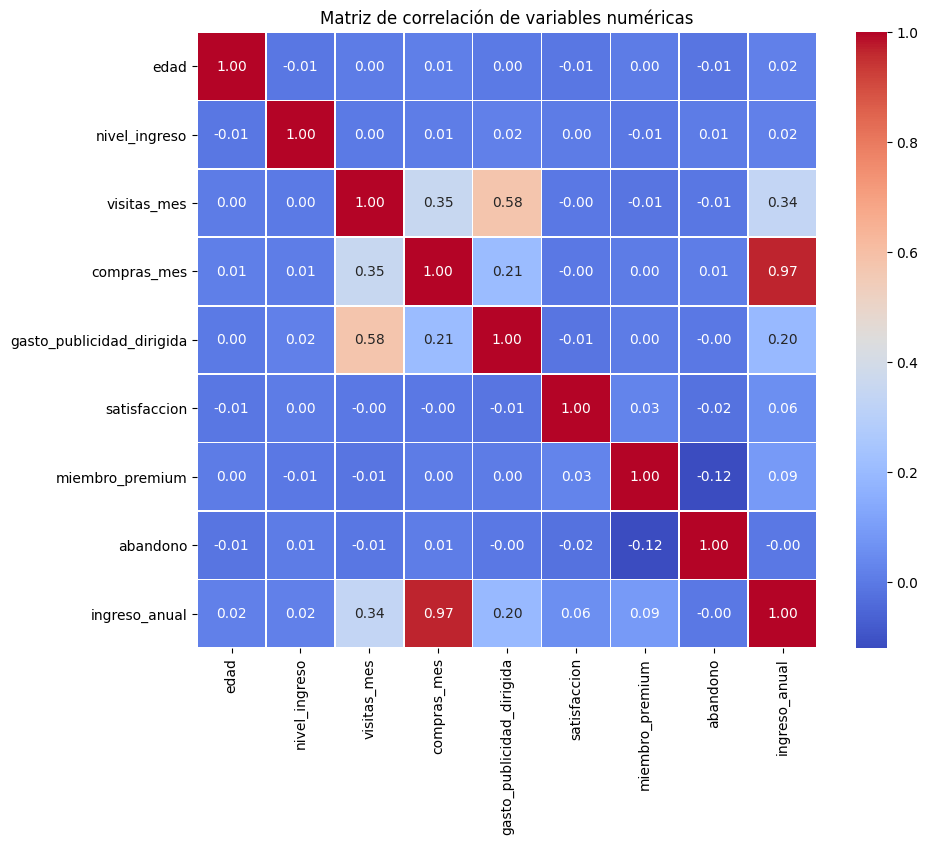

In [13]:
# Visualizar la matriz de correlación para identificar relaciones
columnas_numericas = [
    'edad',
    'nivel_ingreso',
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'satisfaccion',
    'miembro_premium',
    'abandono',
    'ingreso_anual'
]

# Calcular matriz de correlación
matriz_corr = df[columnas_numericas].corr()

# Visualizar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de correlación de variables numéricas')
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- la mayoría de las relaciones entre variables numéricas parecen ser de intensidad baja a moderada, lo que sugiere que no todas las variables del comportamiento del cliente están fuertemente asociadas entre sí. El heatmap permite identificar patrones iniciales de asociación y detectar qué variables podrían merecer una revisión más detallada mediante análisis específicos.


Observaciones respecto a `ingreso_anual`  
- presenta asociaciones más visibles con algunas variables de comportamiento y valor del cliente, lo que sugiere que ciertos factores podrían estar más relacionados con el ingreso generado. Sin embargo, estas relaciones deben interpretarse con cautela, ya que el mapa de correlación solo muestra asociación lineal entre variables numéricas y no implica causalidad.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

In [ ]:
En este caso, el heatmap de correlación ya ofrece una visión global de las asociaciones entre variables numéricas. Por ello, resulta más útil complementar el análisis con scatterplots específicos entre `ingreso_anual` y aquellas variables que muestren relaciones más relevantes en la matriz de correlación.

### Scatterplot para pares clave

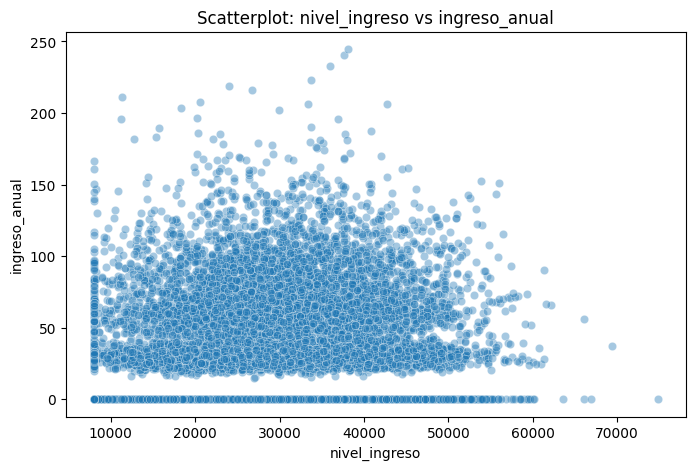

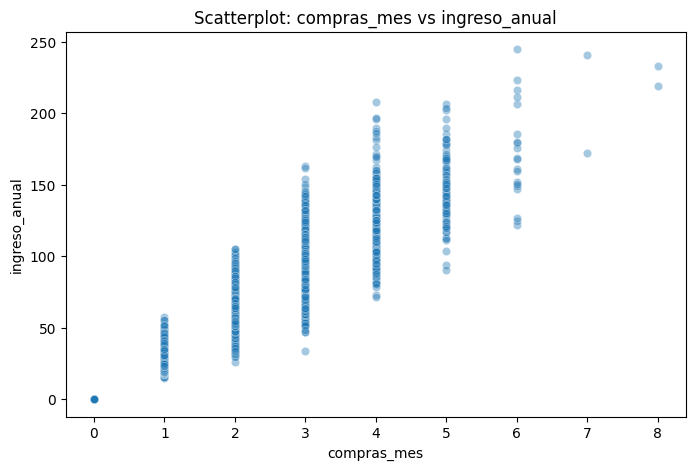

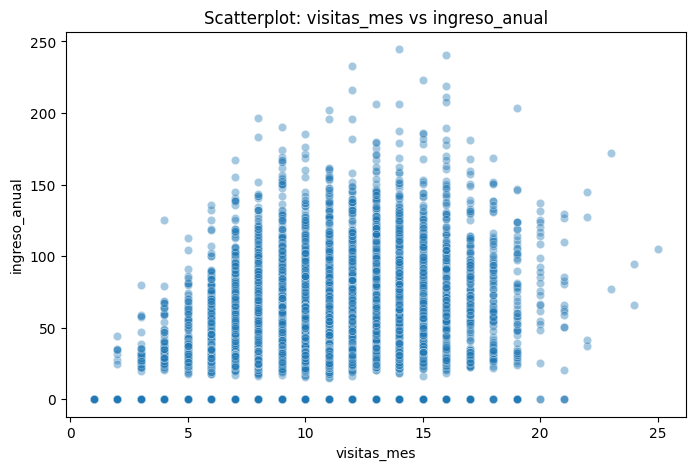

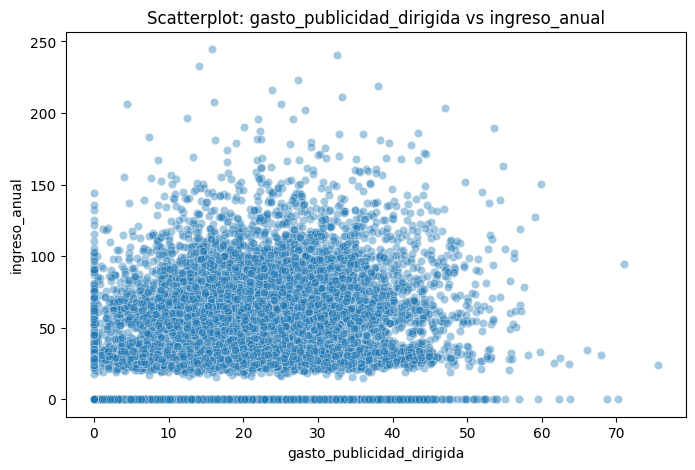

In [14]:
# Visualizar pares de variables con relaciones moderadas o fuertes

variables_clave = ['nivel_ingreso', 'compras_mes', 'visitas_mes', 'gasto_publicidad_dirigida']

for var in variables_clave:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=var, y='ingreso_anual', alpha=0.4)
    plt.title(f'Scatterplot: {var} vs ingreso_anual')
    plt.xlabel(var)
    plt.ylabel('ingreso_anual')
    plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**var1 vs var2**
- Dirección ...
- 

**var1 vs var3**
- Dirección ...
- 

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [1]:
# Calcular correlación entre variables relevantes


In [ ]:
# Calcular correlación entre variables relevantes


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**var1 vs var2**
- correlación positiva/negativa de magnitud débil/moderada/fuerte entre var1 y var2. Esto indica que, a medida que una variable aumenta/disminuye, la otra tiende a aumentar/disminuir en la misma/dirección opuesta. Visualmente, el patrón en el scatterplot sugiere una relación relativamente consistente, aunque con cierta dispersión. Si esta correlación es elevada, podría existir "osible colinealidad", por lo que conviene considerarlo en análisis posteriores
- 

**var2 vs var3**
- correlación positiva/negativa de magnitud débil/moderada/fuerte entre var2 y var3. La relación parece mostrar una tendencia general clara, aunque no necesariamente perfecta. Si ambas variables explican fenómenos similares, esta asociación podría sugerir "solapamiento de información" o una posible colinealidad parcial.
- 

### Punto-biserial

In [15]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

# Calcular correlación punto-biserial entre variables binarias e ingreso_anual
corr_miembro = pointbiserialr(df['miembro_premium'], df['ingreso_anual'])
corr_abandono = pointbiserialr(df['abandono'], df['ingreso_anual'])

print('miembro_premium vs ingreso_anual:')
print(f'Coeficiente: {corr_miembro.statistic:.4f}, p-valor: {corr_miembro.pvalue:.4f}')

print('\nabandono vs ingreso_anual:')
print(f'Coeficiente: {corr_abandono.statistic:.4f}, p-valor: {corr_abandono.pvalue:.4f}')

miembro_premium vs ingreso_anual:
Coeficiente: 0.0931, p-valor: 0.0000

abandono vs ingreso_anual:
Coeficiente: -0.0028, p-valor: 0.7295


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**var1 vs var2**
- La relación entre miembro_premium` e `ingreso_anual es positiva/negativa y de magnitud baja/media/alta. Esto sugiere que pertenecer al grupo con valor 1 en miembro_premium se asocia con un mayor/menor ingreso anual generado para la empresa

**var2 vs var3**
- La relación entre abandono e ingreso_anual es positiva/negativa y de magnitud baja/media/alta. Esto indica que los clientes con valor 1 en abandono tienden a generar un mayor/menor ingreso anual en comparación con quienes no abandonan la plataforma.

### V de Cramér

In [16]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

In [17]:
# Aplicar V de Cramér en variables relevantes
v_tipo_region = cramers_v(df['tipo_dispositivo'], df['region'])
v_tipo_premium = cramers_v(df['tipo_dispositivo'], df['miembro_premium'])
v_region_premium = cramers_v(df['region'], df['miembro_premium'])
v_tipo_abandono = cramers_v(df['tipo_dispositivo'], df['abandono'])
v_region_abandono = cramers_v(df['region'], df['abandono'])

# Mostrar resultados
resultados_cramer = pd.DataFrame({
    'pares': [
        'tipo_dispositivo vs region',
        'tipo_dispositivo vs miembro_premium',
        'region vs miembro_premium',
        'tipo_dispositivo vs abandono',
        'region vs abandono'
    ],
    'V_de_Cramer': [
        v_tipo_region,
        v_tipo_premium,
        v_region_premium,
        v_tipo_abandono,
        v_region_abandono
    ]
})

resultados_cramer


,pares,V_de_Cramer
0,tipo_dispositivo vs region,0.012378
1,tipo_dispositivo vs miembro_premium,0.019725
2,region vs miembro_premium,0.012574
3,tipo_dispositivo vs abandono,0.007245
4,region vs abandono,0.015430


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér
]


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 — La frecuencia de compra parece estar asociada con un mayor ingreso anual

El scatterplot entre compras_mes e ingreso_anual muestra una tendencia ascendente general, lo que sugiere que los clientes que realizan más compras al mes tienden a generar mayores ingresos anuales. Aunque existe dispersión, el patrón visual apunta a una asociación positiva.

**Evidencia numérica:**  
La matriz de correlación muestra una relación positiva entre compras_mes e ingreso_anual, con una magnitud que debe interpretarse como la más relevante o una de las más relevantes dentro de las variables numéricas analizadas.

**Interpretación**  
Esto sugiere que la frecuencia de compra es un comportamiento estrechamente vinculado con el valor económico generado por el cliente. En términos exploratorios, los clientes con mayor actividad transaccional tienden a aportar más ingreso anual a la empresa.

**No podemos afirmar**  
No podemos afirmar que aumentar directamente el número de compras cause por sí mismo un incremento en el ingreso anual, ya que el análisis es correlacional y no controla por otros factores como nivel de ingreso, satisfacción, campañas de marketing o membresía premium.

**Implicación de negocio**  
Este hallazgo sugiere que NovaRetail+ podría priorizar estrategias orientadas a incrementar la frecuencia de compra, como promociones personalizadas, recordatorios de recompra, programas de fidelización o recomendaciones de productos, especialmente en segmentos con alto potencial de crecimiento.


### Hallazgo 2 — La membresía premium parece estar asociada con un mayor ingreso anual

**Evidencia visual:**  
Al comparar visualmente a los clientes con y sin membresía premium, se observa que el grupo premium tiende a concentrar valores más altos de `ingreso_anual`.

**Evidencia numérica:**  
La correlación punto-biserial entre `miembro_premium` e `ingreso_anual` muestra una relación positiva, lo que indica que los clientes con valor 1 en la variable `miembro_premium` tienden a generar mayores ingresos anuales que aquellos sin suscripción.

**Interpretación**  
Esto sugiere que la membresía premium está asociada con un mayor valor económico del cliente. Es posible que este segmento tenga una mayor recurrencia, mayor engagement o un perfil de consumo más rentable para la empresa.

**No podemos afirmar**  
No podemos afirmar que la membresía premium cause directamente un mayor ingreso anual. También es posible que los clientes con mayor valor previo sean precisamente quienes tienen más probabilidad de suscribirse al servicio premium.

**Implicación de negocio**  
Este hallazgo sugiere que NovaRetail+ podría profundizar en estrategias de adquisición, conversión y retención de usuarios premium, así como evaluar mediante experimentos si ciertos beneficios premium impulsan efectivamente un mayor valor económico.


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación no implica causalidad.
- El análisis es exploratorio y no concluyente.
- Pueden existir variables relevantes no incluidas en el dataset.
- Algunas relaciones complejas o no lineales podrían no reflejarse completamente en los coeficientes utilizados.- 

### **Próximos pasos** 

Probar segmentación adicional
### Paso 1: Probar segmentación adicional
- Por nivel de ingreso
- Por membresía premium
- Por región

### Paso 2: Profundizar el análisis descriptivo
- Comparar grupos clave
- Incorporar boxplots
- Revisar distribuciones por segmento

### Paso 3: Validar hallazgos
- Diseñar experimentos
- Construir modelos predictivos
- Evaluar variables en conjunto

In [3]:

import pandas as pd

df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')

# Guardar una copia en el entorno del notebook
df.to_csv('novaretail_exportado.csv', index=False)